## TASK 1. PROJECT OVERVIEW & KEY LEARNING OBJECTIVES

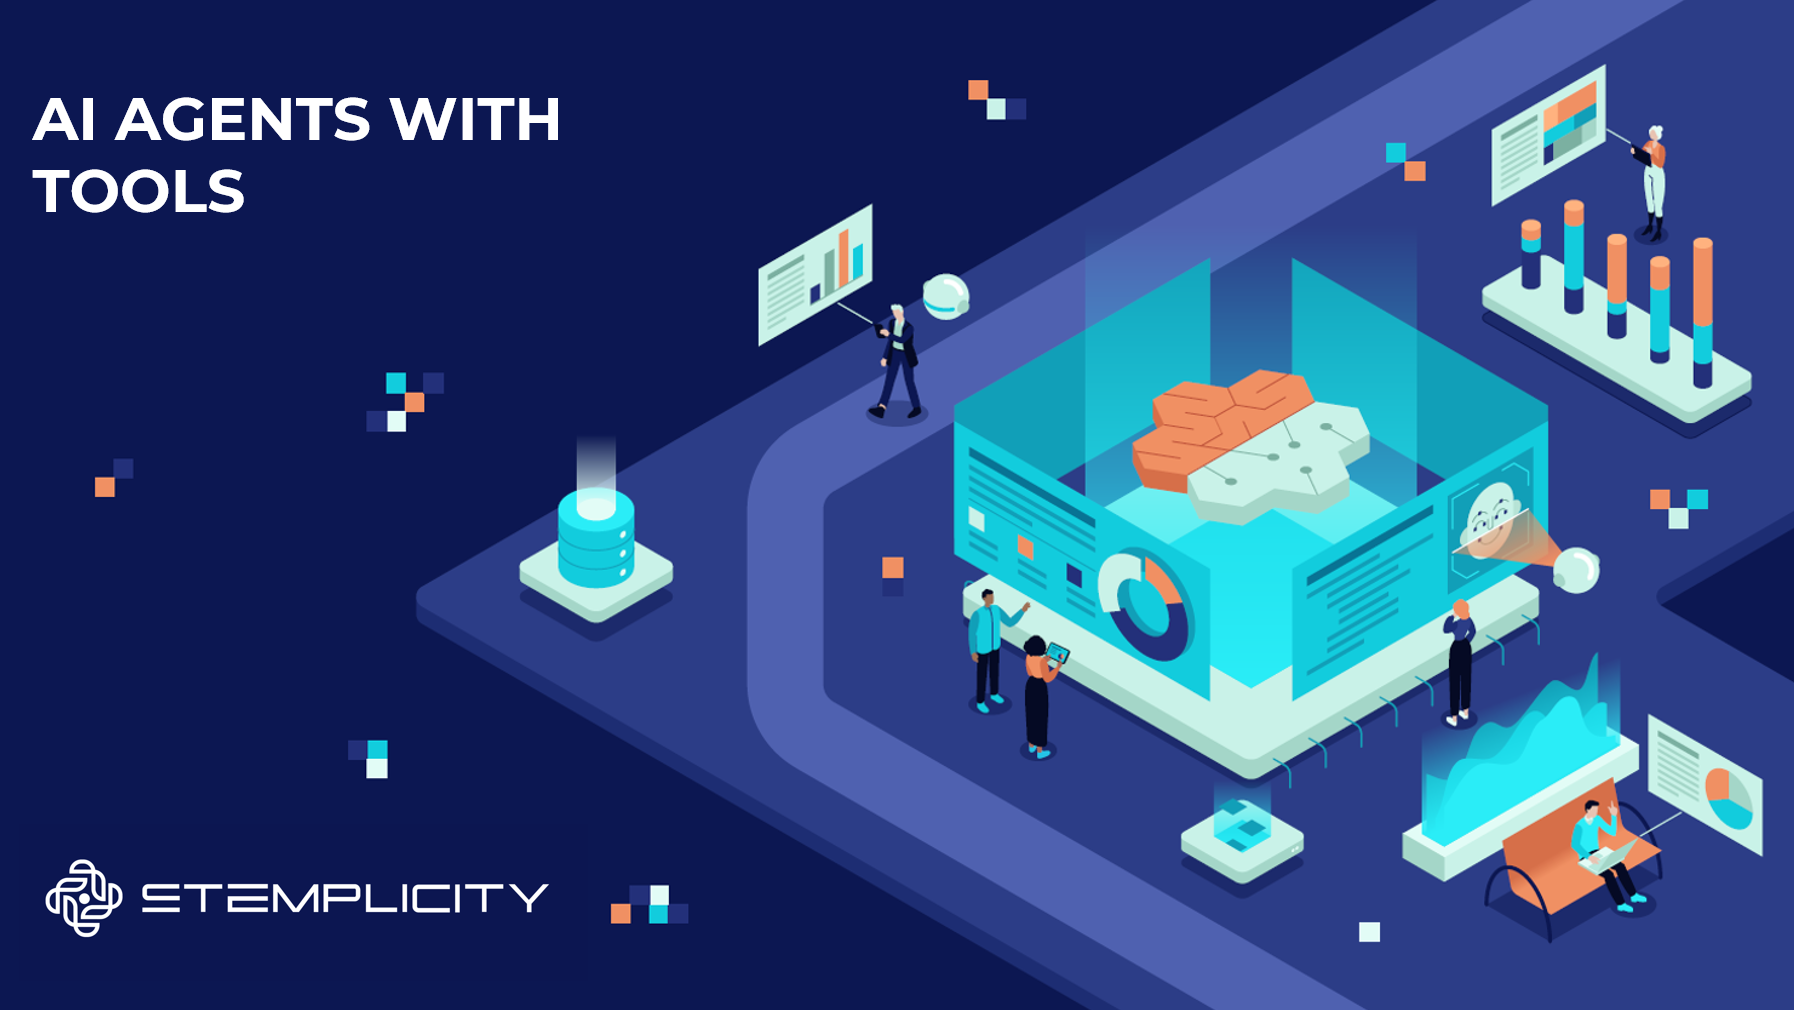

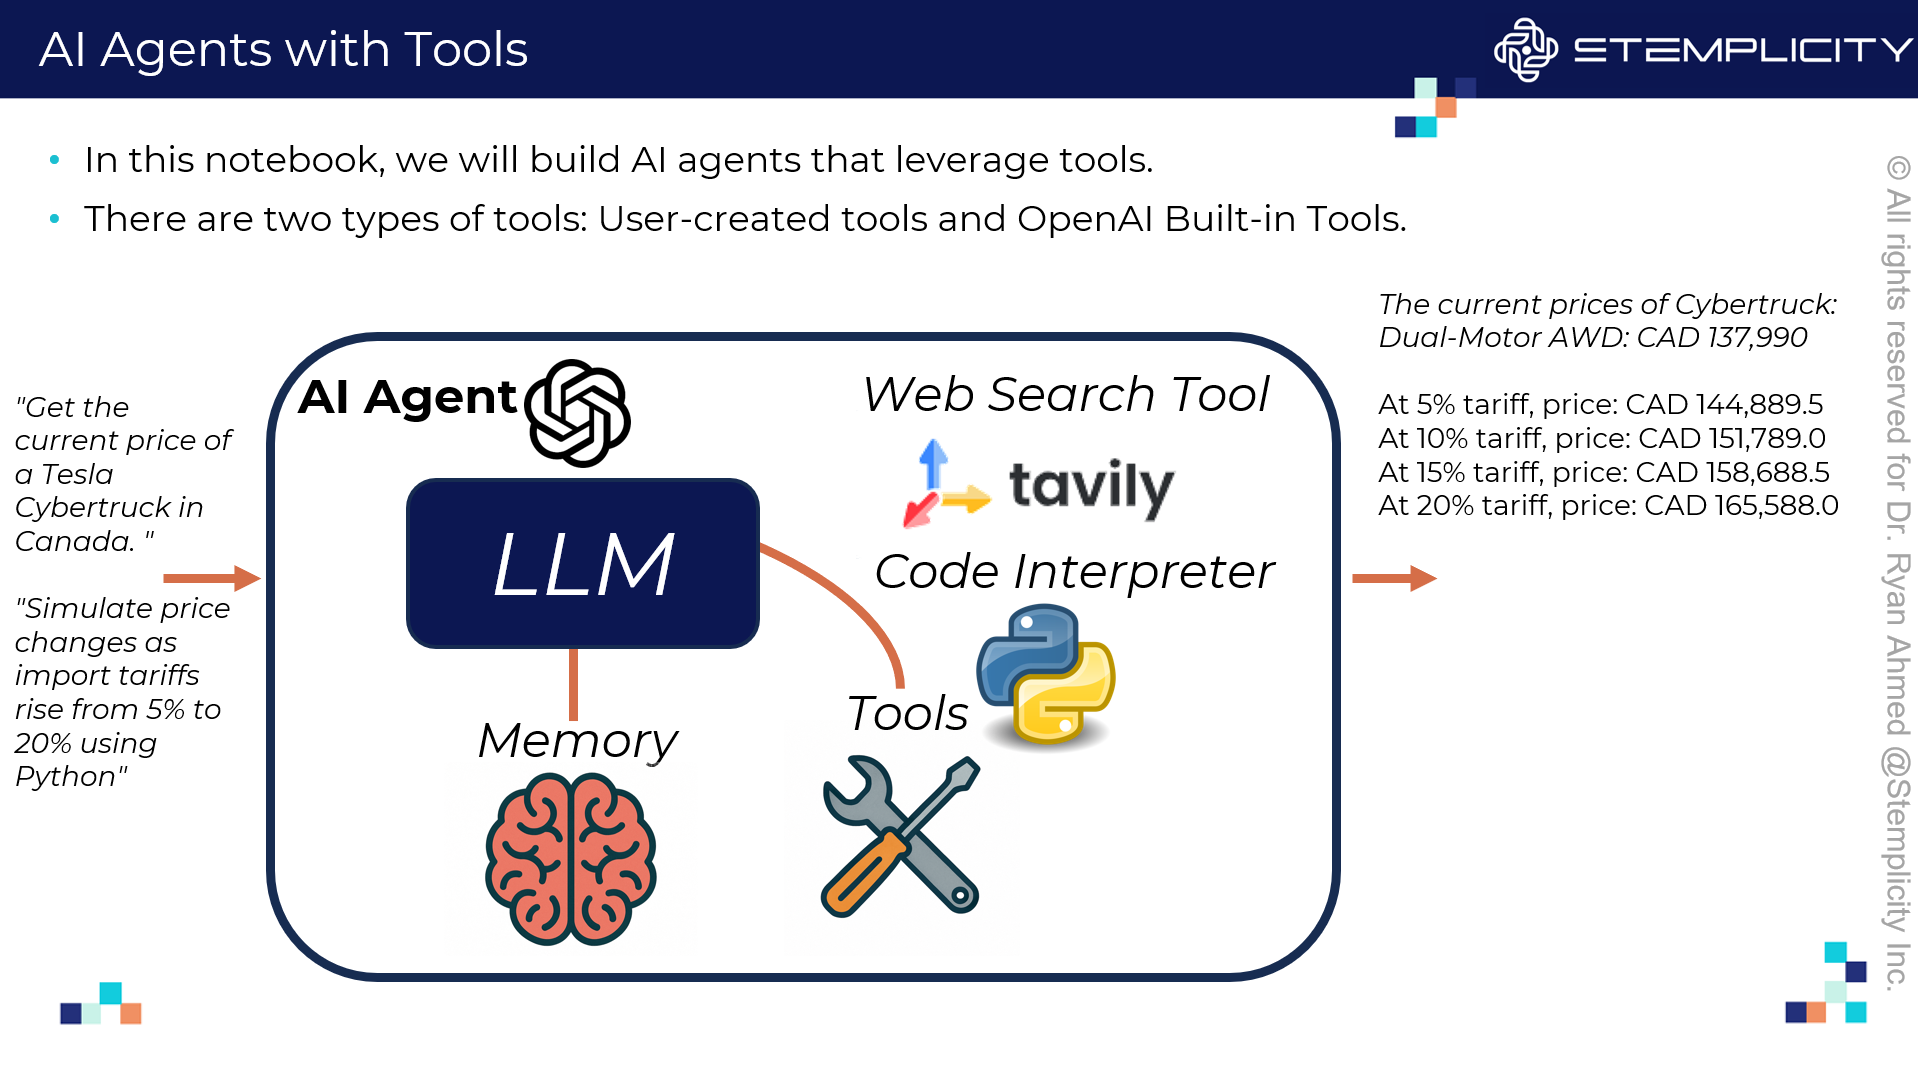

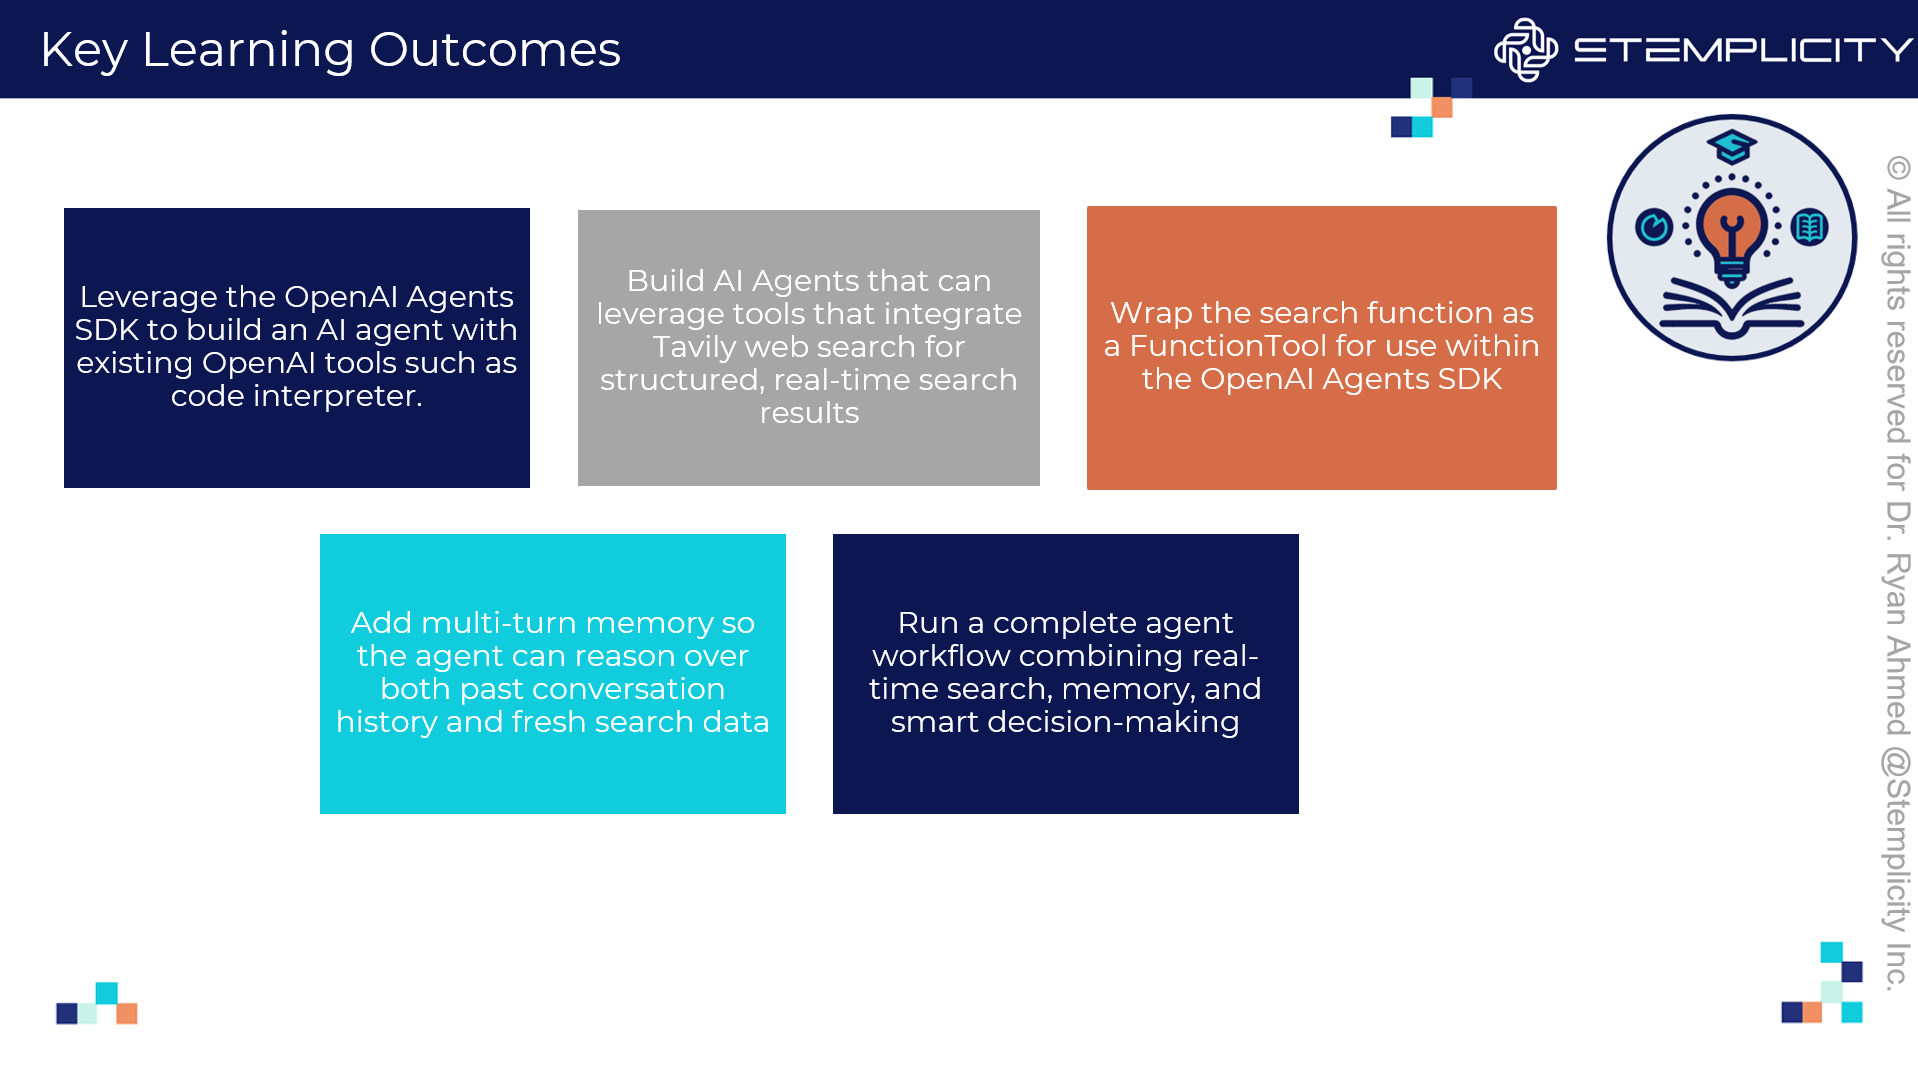

## TASK 2. SETUP OPENAI AND TAVILY API KEYS

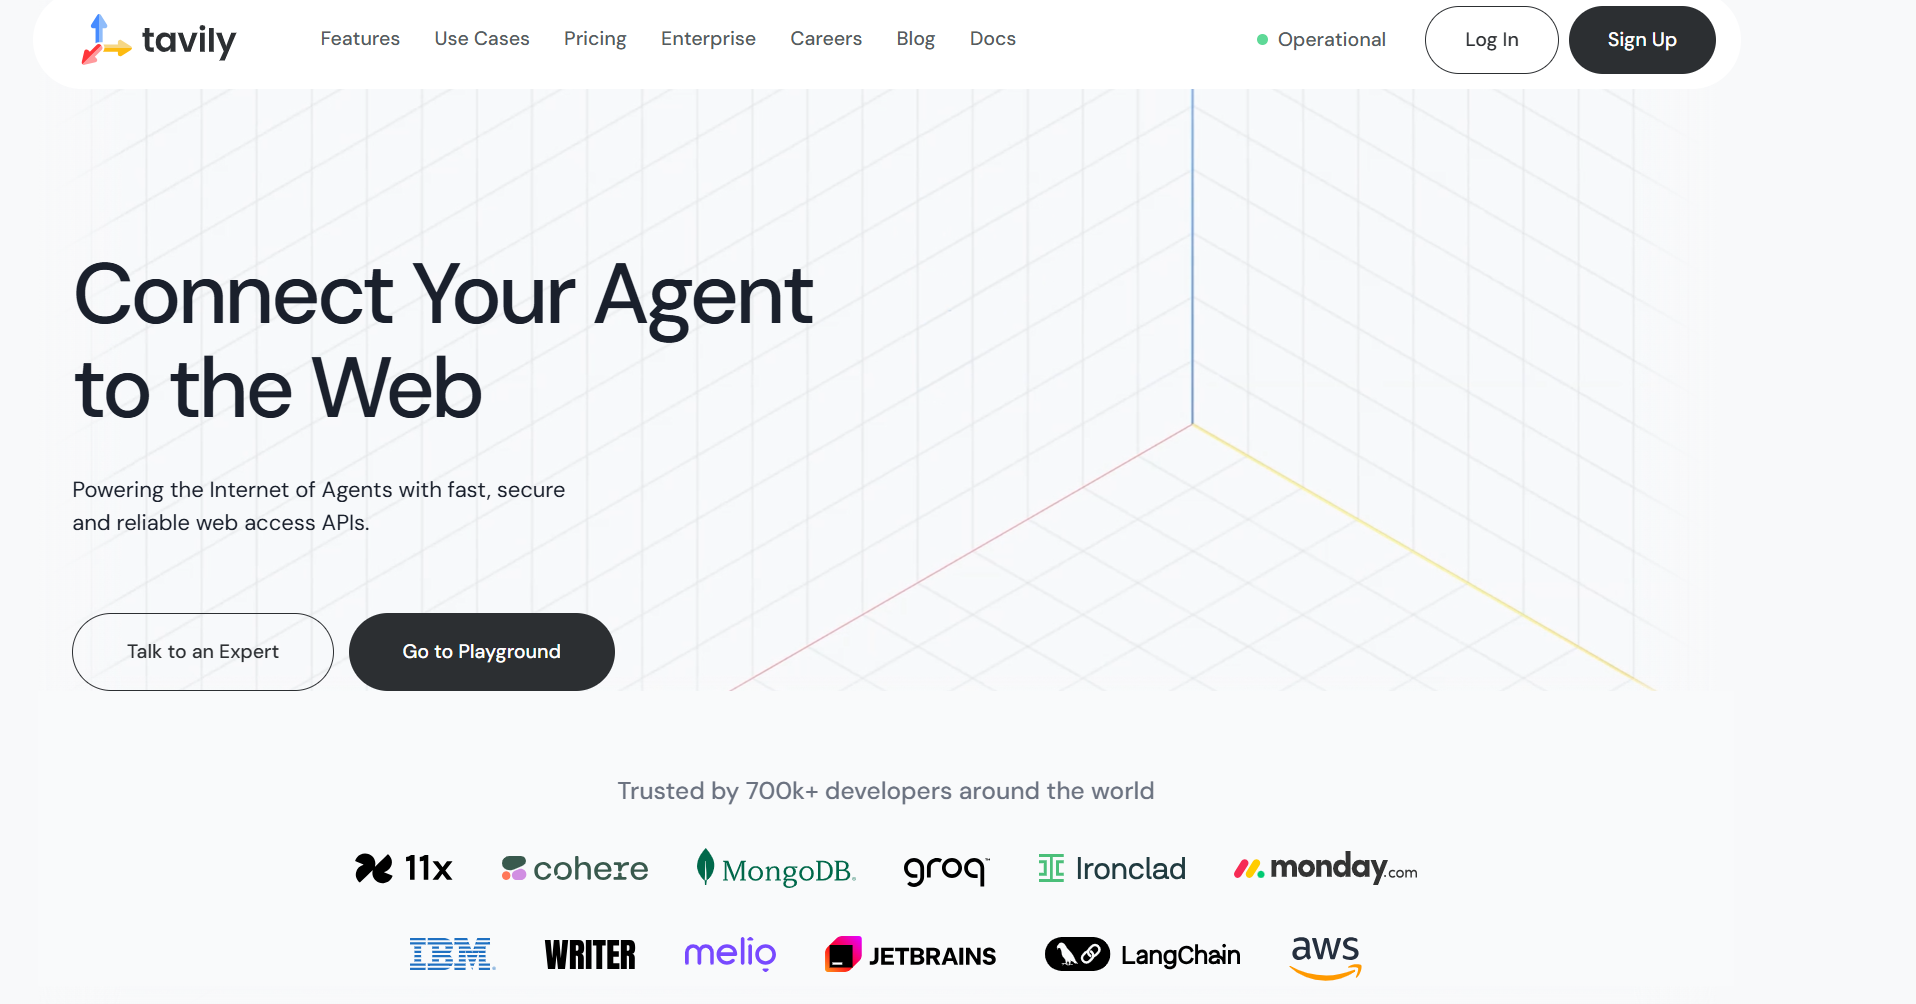

- Tavily is a platform that gives AI agents reliable, structured web access via an easy API, streamlining search workflows.
- Link: https://tavily.com/.
- Action:
    - Sign up for Tavily Self-Service API if you haven't already.
    - Create a .env file in the same directory as this notebook (if you don't have one).
    - Add your keys to the .env file like this:
      - **OPENAI_API_KEY=sk-YourSecretOpenAIKey...**
      - **TAVILY_API_KEY=tvly-YourSecretTavilyKey...**


In [1]:
!pip install -q openai-agents==0.2.2 python-dotenv requests

In [2]:
import os
import asyncio
from openai import AsyncOpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown
from agents import set_default_openai_client, set_default_openai_api, set_tracing_disabled

# Load environment variables and configure client
load_dotenv()

openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

# 1. Create a custom async client pointing to OpenRouter
or_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=openrouter_api_key
)
    
# 2. Inject it into the Agents SDK
set_default_openai_client(or_client)
    
# 3. CRITICAL: Force the SDK to use Chat Completions 
# (OpenRouter does not support OpenAI's proprietary Responses API)
set_default_openai_api("chat_completions")

# 4. Disable telemetry to prevent the 401 error
set_tracing_disabled(True)

# Check the API Keys
print(f"Openrouter API Key: {openrouter_api_key[:5]}")
print(f"Tavily API Key: {tavily_api_key[:5]}")

print("OpenAI client configured.")


Openrouter API Key: sk-or
Tavily API Key: tvly-
OpenAI client configured.


In [3]:
def print_markdown(text: str):
    display(Markdown(text))

## TASK 3: DEFINE TAVILY SEARCH FUNCTION & CREATE A TOOL

In [4]:
import requests
import json  # Import the json module for handling JSON data
from typing_extensions import TypedDict  # Import TypedDict for type hinting
from agents import function_tool

In [5]:
# Define a TypedDict for the expected parameters for the Tavily search function
# A TypedDict is like a blueprint for a dictionary in Python
# It tells Python exactly what keys the dictionary should have and what type of values go with each key.

class TavilySearchParams(TypedDict):
    query: str         # The search query string
    max_results: int   # The maximum number of results to return

In [6]:
# Let's define a function that searches the web using the Tavily API and gives back a short summary of the top results.
# Decorate the function as a FunctionTool for OpenAI Agents SDK
@function_tool
def tavily_search(params: TavilySearchParams) -> str:
    """
    Calls the Tavily API and returns a string summary of top search results.

    Args:
        params (TavilySearchParams): Dictionary with 'query' (str) and 'max_results' (int).

    Returns:
        str: A formatted string summarizing the top search results, or an error message.
    """

    # The web address (endpoint) for sending search requests to Tavily ( Tavily API endpoint)
    url = "https://api.tavily.com/search" 

    # Tell the API that we’re sending JSON data
    headers = {"Content-Type": "application/json"}  

    # What we’re sending to the API:
    # Our secret API key (so Tavily knows it's us)
    # The search text (query)
    # How many results we want (defaults to 2 if not given)
    payload = {
        "api_key": tavily_api_key,  # Use the Tavily API key from environment
        "query": params["query"],   # The search query from params
        "max_results": params.get("max_results", 2),  # Use max_results from params, default to 2 if not provided
    }

    # Send the search request to Tavily (POST means we’re sending data)
    response = requests.post(url, json = payload, headers = headers) 

    # Check if the search worked (200 = OK)
    if response.status_code == 200:  # If the request was successful
        results = response.json().get("results", [])  # Extract the 'results' list from the response JSON
        
        # Build a summary string with each result's title and content, numbered
        summary = "\n".join([f"{i+1}. {r['title']}: {r['content']}" for i, r in enumerate(results)])
        return summary if summary else "No relevant results found."  # Return summary or fallback message
    else:
        return f"Tavily API error: {response.status_code}"  # Return error message with status code if request failed


**PRACTICE OPPORTUNITY:**
- **Modify the tavily_search function so that it returns only the titles of the search results, without including the content.**
- **Increase the number of results returned from 2 to 3 by updating the max_results parameter in the function.**

## TASK 4: BUILD AND RUN AN AI AGENT WITH SEARCH TOOL 

In [10]:
# Let's add memory to our agent
from agents import SQLiteSession
session = SQLiteSession("live_researcher_practice")

In [11]:
from agents import Agent

instructions = """
CONTEXT:
You are a world-class market research assistant with access to real-time web search via the tavily_search tool.

INSTRUCTION:
- Analyze the user's question and determine if recent or real-time information is needed.
- If the question involves recent events, news, or product info, always call tavily_search.
- Summarize search results clearly and concisely, do not copy-paste.
- Always start your answer with: "🔍 According to a web search …"

INPUT:
You will receive a conversation history and the latest user question. Use the full context to inform your response.

OUTPUT:
Provide a clear, well-structured answer that references the search results when appropriate. If you use tavily_search, integrate the findings into your summary.
"""

live_researcher_agent = Agent(name = "Live Market Researcher",
                             instructions = instructions,
    model = "nemotron-nano-9b-v2:free",
    tools = [tavily_search])

print("✅ Agent created with Tavily tool.")

✅ Agent created with Tavily tool.


In [12]:
from agents import Runner

# First question
q1 = "What's the public sentiment on latest protest by veteran scientist Sonam Wangchuk in India?"

print_markdown(f"**User:** {q1}")

run1 = await Runner.run(
    starting_agent = live_researcher_agent,
    input = q1,
    session = session,
)

print_markdown(f"### 🤖 Agent’s Answer\n{run1.final_output}")


**User:** What's the public sentiment on latest protest by veteran scientist Sonam Wangchuk in India?

### 🤖 Agent’s Answer
🔍 According to a web search, public sentiment around Sonam Wangchuk's protest in India is mixed but largely focused on support for his cause. Key points include:  

1. **Support and Engagement**: Wangchuk’s hunger strike, led under the Cockroach Janta Party (CJP), has gained significant traction, particularly among youth via social media (e.g., 22 million Instagram followers for the CJP in a short time). Thousands joined protests, and political parties showed solidarity, indicating broad public backing for educational reforms.  

2. **Health Concerns**: His deteriorating health (loss of 8.2kg, low blood pressure) has raised worries, potentially softening public sympathy or inviting criticism of the protest’s intensity.  

3. **Criticism of Police Action**: Wangchuk’s comparison of Delhi Police treatment to Swiss authorities sparked debate, with some supporting his critique of law enforcement and others questioning hisComparison or the protest’s methods.  

4. **Government Response**: His arrest raised tensions, with protesters demanding the resignation of education ministers. This has amplified the movement’s visibility but also risks alienating moderate voices.  

Overall, sentiment reflects a polarized but active public, with strong grassroots support for the CJP’s demands and growing concern over Wangchuk’s welfare and the protest’s escalation.


- **Note: You can monitor all tools used by the Agent through traces, available in the OpenAI platform when you log in to your account.**
- **Link: https://platform.openai.com/logs/**

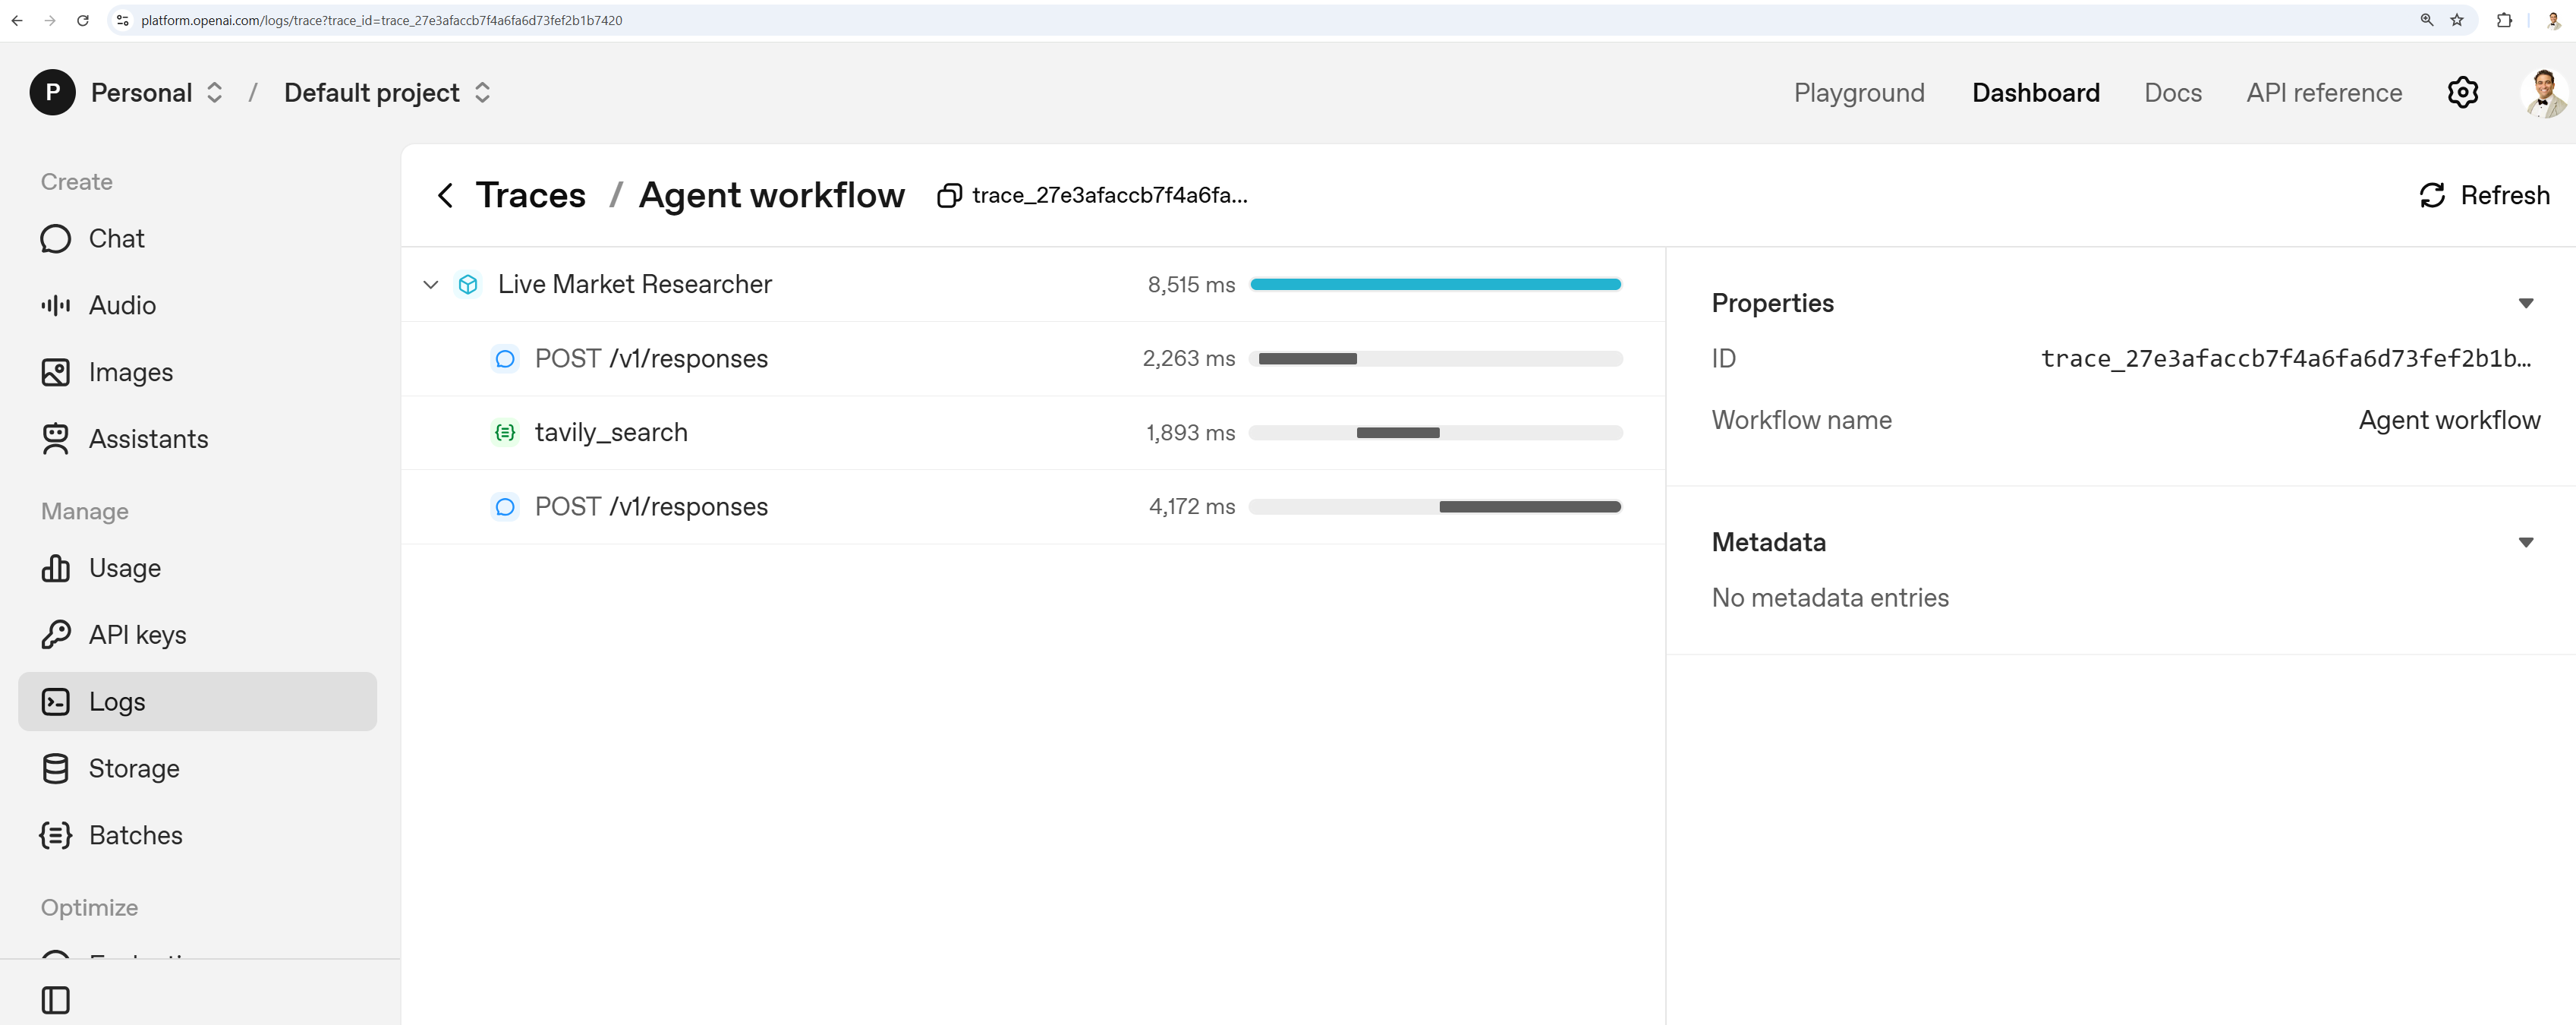

**PRACTICE OPPORTUNITY:**  
- **Use the `live_researcher_agent` AI agent to find and summarize the key features of your favorite vehicle, it can be electric or conventional.**  
    - **Example:** *"What do reviewers say about the new Cybertruck?"*  
    - **Then test its memory and search ability with a follow-up:** *"Summarize the main features."*  

In [14]:
q2 = "What do the critics and reviewers say on Tata Sierra"

print_markdown(f"User: {q2}")

response = await Runner.run(
    input = q2,
    starting_agent= live_researcher_agent,
    session= session
)

print_markdown(f"Agent's Answer :\n {response.final_output}")

User: What do the critics and reviewers say on Tata Sierra

Agent's Answer :
 

🔍 According to a web search, critics and reviewers of the Tata Sierra present a mixed but generally balanced perspective. Key points include:  

### **Criticisms and Concerns**:  
1. **Build Quality and Fit & Finish**: Multiple reviews note inconsistent quality in cabin materials and sub-par fit and finish compared to segment standards.  
2. **Engine Noise**: Diesel variants are criticized for being loud, while petrol models have better insulation but still room for improvement.  
3. **Reliability**: Experts express concerns about the long-term reliability of dual-clutch automatic transmissions (DCT) and new powertrains/tested tech.  
4. **After-Sales Service**: Tata’s service quality is described as inconsistent, with mixed experiences reported by users.  
5. **Niggles in Tech**: New features and software have been flagged for potential bugs or unresolved issues in early reviews.  

### **Positive Feedback**:  
1. **Design and Spaciousness**: Praised for its stylish appearance, large boot, and ability to seat 5 adults comfortably.  
2. **Value for Money**: Many users, especially from the middle class, highlight it as an affordable yet feature-rich option.  
3. **Performance**: The 116 BHP turbo-petrol engine is noted for decent highway performance and a refined ride/drive experience.  
4. **Desirability**: Declared as "the best family SUV in India" by some reviewers for its balance of features and price.  

### **Overall Tone**:  
While critics emphasize areas needing improvement (especially in quality control and reliability), user reviews and expert assessments largely position the Tata Sierra as a strong contender for budget-conscious buyers prioritizing practicality and features. The concerns are seen as typical for a newly launched model in a competitive segment.


In [15]:
followup_question = "Do you suggest buying it now in Indian?"

print_markdown(f"User: {followup_question}")

response = await Runner.run(
    input=followup_question,
    starting_agent=live_researcher_agent,
    session=session
)

print_markdown(f"Agent's Response: \n {response.final_output}")

User: Do you suggest buying it now in Indian?

Agent's Response: 
 

🔍 Based on current reviews and market trends in India, here's a balanced perspective to help you decide:

### **Reasons to Consider Buying Now**:
1. **Value for Money**: Many users praise its affordability and feature set for middle-class buyers.  
2. **Desirability**: Stylish design, large boot, and 5-seat capacity make it practical for families.  
3. **Performance**: The turbo-petrol engine offers decent highway capability and a refined ride.  

### **Key Concerns to Weigh**:
1. **Build Quality**: Inconsistent fit/finish and cabin material quality may affect long-term satisfaction.  
2. **Reliability**: New DCT transmissions and software have unresolved bug concerns in early reviews.  
3. **After-Sales Service**: Tata’s service network is described as hit-or-miss, which could impact maintenance costs.  

### **Recommendation**:
If you prioritize **budget-friendly practicality** and can tolerate potential teething issues (common with new models), it could be a solid choice. However, if reliability and premium build quality are non-negotiable, you might wait for:  
- Further reliability data (after 6–12 months of real-world use).  
- Competitor releases (e.g., Hyundai Creta, Kia Sonet) that might address these gaps.  

⚠️ **Next Steps**:  
- Test-drive multiple variants (petrol vs. diesel).  
- Check service history if buying used.  
- Clarify if you need specific features (e.g., tech, off-road capability).  

Would you like help narrowing down based on your priorities (e.g., budget, family size, usage)?


## TASK 5. LEVERAGE EXISTING OPENAI BUILT-IN TOOLS

- Instead of creating a tool, you can leverage existing tools available in OpenAI Agents SDK: https://openai.github.io/openai-agents-python/ref/tool/
    - **WebSearchTool:** Let your agent do a real‑time web search 
    - **FileSearchTool:** Search your vector stores for content retrieval 
    - **ComputerTool:** Have the agent take actions on your system like clicking or typing 
    - **CodeInterpreterTool, ImageGenerationTool, HostedMCPTool:** Extra built‑ins for code, visuals, MCP connections all ready to go

In [16]:
import json  # Import the json module for handling JSON data
from typing_extensions import TypedDict, Any  # Import TypedDict for type hinting, Any for general typing

# from agents import FunctionTool, function_tool, RunContextWrapper, CodeInterpreterTool # Import agent tool decorators and helpers
from agents import FunctionTool, function_tool, CodeInterpreterTool # Import agent tool decorators and helpers

# Use the hosted CodeInterpreterTool to provide a safe, sandboxed Python execution environment for the agent.
# This tool allows the agent to run Python code in a secure container, which is isolated from the main system.
# The 'tool_config' specifies that we want an automatic container (per documentation).
code_interpreter = CodeInterpreterTool(
    tool_config = {"type": "code_interpreter", 
                   "container": {"type": "auto"}})

# Print a message to confirm that all tools (get_catalog, run_readonly_sql, code_interpreter) are ready for use.
print("✅ Tool ready: code_interpreter")

✅ Tool ready: code_interpreter


In [17]:
instructions = """
CONTEXT:
You are a world-class market research assistant with access to both real-time web search (via the tavily_search tool) and Python code execution (via the code_interpreter tool).

INSTRUCTION:
- Carefully analyze the user's question to determine whether it requires:
    - Recent or real-time information (use tavily_search),
    - Data analysis, calculations, or code execution (use code_interpreter),
    - Or a combination of both tools.
- Use tavily_search for up-to-date facts, news, or product information.
- Use code_interpreter for tasks involving data analysis, calculations, or code-based reasoning.
- If the task benefits from both tools, use them together and integrate the results.
- Clearly summarize your findings and reasoning. Do not copy-paste search results; always paraphrase.
- When using search, begin your answer with: "🔍 According to a web search …"
- When using code, explain your process and results clearly.

INPUT:
You will receive a conversation history and the latest user question. Use the full context to decide which tool(s) to use and to inform your response.

OUTPUT:
Provide a clear, well-structured answer. Reference search results and/or code outputs as appropriate, and integrate them into your summary.
"""

In [18]:
from agents import Agent

analyst_agent = Agent(name = "Analyst Agent",
                      instructions = instructions,
    model = "nemotron-nano-9b-v2:free",
    tools = [tavily_search, code_interpreter],
)

print("✅ Agent created with Tavily and Code Interpreter tools.")

✅ Agent created with Tavily and Code Interpreter tools.


In [ ]:
session = SQLiteSession("live_researcher")

# New question: Ask the agent to get the current price of a Tesla Cyber Truck in India,
# then simulate the price increase if tariffs rise from 5% to 20% in 1% increments,
# and calculate the new prices using Python, providing a summary across all scenarios.

q1 = (
    "Find the current price of a Tesla Cyber Truck in India. "
    "Then, simulate how the price would change if import tariffs increased from 5% to 20% in 1% increments. "
    "For each tariff rate, calculate the new price using Python and provide a summary of the results across all scenarios."
)

print_markdown(f"**User:** {q1}")

run1 = await Runner.run(
    starting_agent = analyst_agent,
    input = q1,
    session = session,
)

print_markdown(f"### 🤖 Agent’s Answer\n{run1.final_output}")

We can't use OpenAI Agent SDK's cloud hosted function tools with OpenRouter because when we point baseurl to openrouter we loose access to the secure sandboxes running on OpenAI's private servers and thus we can't execute them.

There are 2 solutions to this:
1. Build and use a local function tool
2. Create your own cloud-hosted sandbox and run the agent's code there. E2B is an industry standard for cloud hosted sanboxes.

## How to use an E2B Hosted Sandbox

Steps to do this:

1.  First, install their code interpreter package:
 ```bash
 pip install e2b_code_interpreter
 ```

2. Then, you can wrap their cloud sandbox into a simple function tool and pass it to your agent. Here is how you modify your script:
```py
import asyncio
from openai import AsyncOpenAI
from agents import set_default_openai_client, set_default_openai_api, set_tracing_disabled, Agent, Runner
from e2b_code_interpreter import Sandbox

# 1. Define the cloud-hosted tool using E2B
def run_hosted_python(code: str) -> str:
    """Executes python code in a secure cloud sandbox. Use this for math, data analysis, etc."""
    try:
        # This spins up an isolated cloud environment in milliseconds
        with Sandbox() as sandbox:
            execution = sandbox.run_code(code)
            
            if execution.error:
                return f"Error: {execution.error.name} - {execution.error.value}"
            
            # Capture standard output
            results = "\n".join(execution.logs.stdout)
            
            # Capture any rich output (like cell evaluations)
            for result in execution.results:
                results += f"\n{result.text}"
                
            return results or "Execution successful with no output."
    except Exception as e:
         return f"Failed to execute in cloud: {e}"

async def main():
    set_tracing_disabled(True)
    
    # Standard OpenRouter setup
    or_client = AsyncOpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key="<YOUR_OPENROUTER_KEY>"
    )
    set_default_openai_client(or_client)
    set_default_openai_api("chat_completions")
    
    # 2. Pass your new cloud-hosted tool to the agent
    agent = Agent(
        name="Data Analyst",
        instructions="You are a data assistant. Write and run python code to solve math problems.",
        model="anthropic/claude-3.5-sonnet", # OpenRouter slug
        tools=[run_hosted_python] # <--- Cloud tool replacing OpenAI's built-in tool
    )
    
    result = await Runner.run(agent, "Calculate the 20th Fibonacci number.")
    print(result.final_output)

if __name__ == "__main__":
    asyncio.run(main())
```

**Note**: You will need to grab a free API key from E2B and set it as an environment variable (E2B_API_KEY) before running the script, just like you did with your OpenRouter key.

# PRACTICE OPPORTUNITY SOLUTIONS

**PRACTICE OPPORTUNITY SOLUTION:**
- **Modify the tavily_search function so that it returns only the titles of the search results, without including the content.**
- **Increase the number of results returned from 2 to 3 by updating the max_results parameter in the function.**

In [ ]:
@function_tool
def tavily_search(params: TavilySearchParams) -> str:
    """
    Calls the Tavily API and returns a string of only the titles
    from the top search results.
    """
    url = "https://api.tavily.com/search"  # Tavily API endpoint
    headers = {"Content-Type": "application/json"}  # Request headers
    payload = {
        "api_key": tavily_api_key,
        "query": params["query"],  # Search query from params
        "max_results": params.get("max_results", 3)  # Default 3 results instead of 2
    }

    response = requests.post(url, json=payload, headers=headers)

    if response.status_code == 200:
        results = response.json().get("results", [])
        
        # Only return numbered titles
        summary = "\n".join([f"{i+1}. {r['title']}" for i, r in enumerate(results)])
        
        return summary if summary else "No relevant results found."
    else:
        return f"Tavily API error: {response.status_code}"


**PRACTICE OPPORTUNITY SOLUTION:**  
- **Use the `live_researcher_agent` AI agent to find and summarize the key features of your favorite vehicle, it can be electric or conventional.**  
    - **Example:** *"What do reviewers say about the new Cybertruck?"*  
    - **Then test its memory and search ability with a follow-up:** *"Summarize the main features."*  

In [ ]:
from agents import Runner

session = SQLiteSession("live_researcher_practice")

prod_memory = []
q1 = "What do reviewers say about the new Tesla Cybertruck?"

print_markdown(f"**User:** {q1}")
run1 = await Runner.run(live_researcher_agent, q1, session = session)
print_markdown(f"**Answer:** {run1.final_output}")

In [ ]:
q2 = "Summarize the main features in one paragraph"
print_markdown(f"**User:** {q2}")
run2 = await Runner.run(live_researcher_agent, q2, session = session)
print_markdown(f"**Answer:** {run2.final_output}")


- **Would love to connect with everyone on LinkedIn: www.linkedin.com/in/dr-ryan-ahmed**

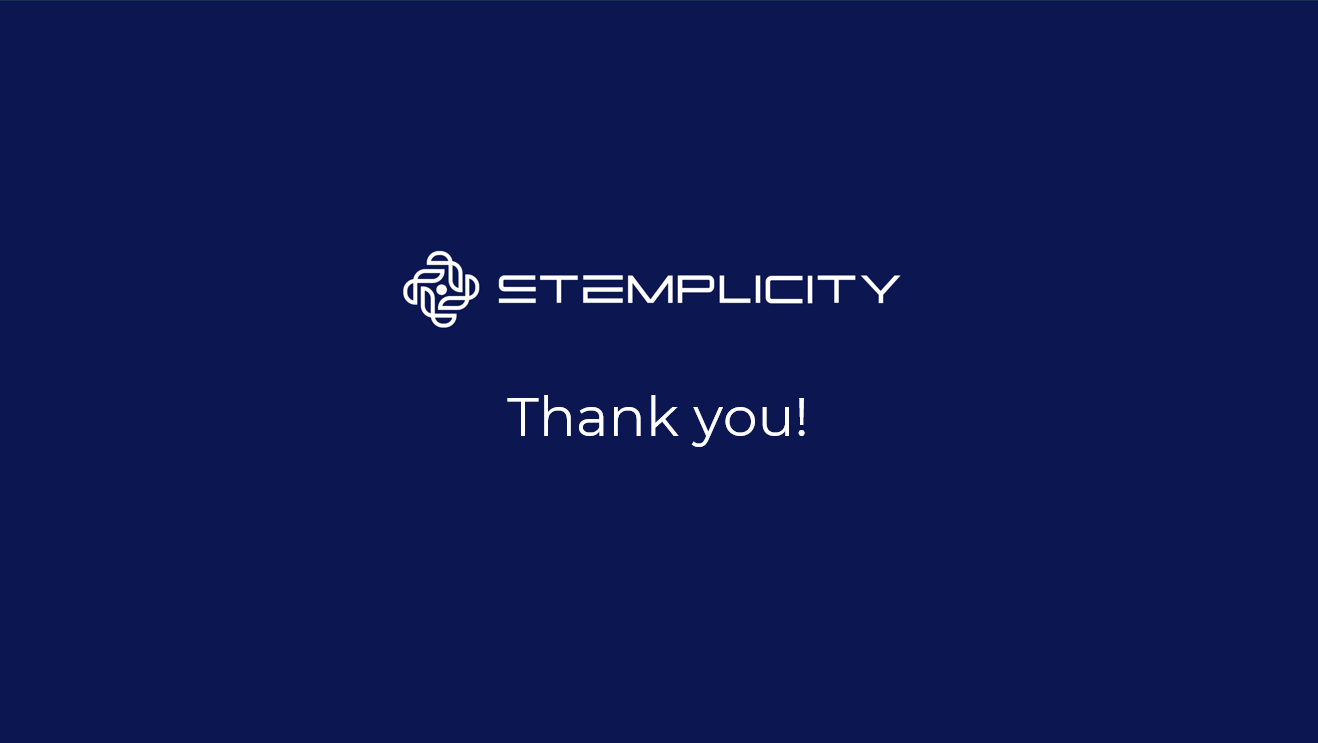